House Price Prediction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/nunnarilabs/ml/master/house/kc_house_data.csv"
df = pd.read_csv(url)

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [4]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [7]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [8]:
corr = df.corr(numeric_only=True)
corr

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


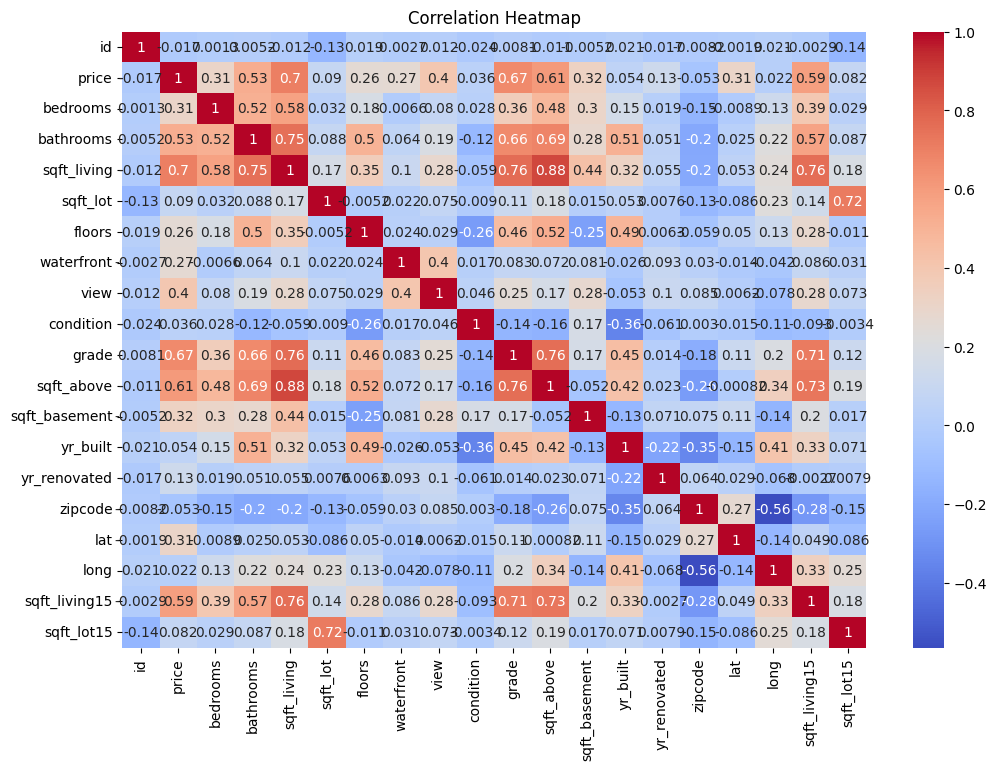

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

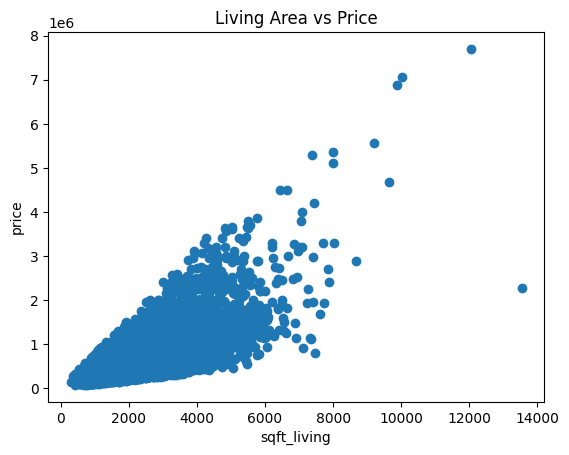

In [10]:
plt.scatter(df['sqft_living'], df['price'])
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.title("Living Area vs Price")
plt.show()

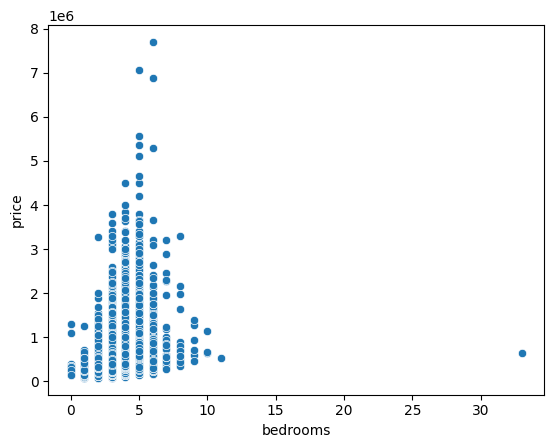

In [11]:
sns.scatterplot(x='bedrooms', y='price', data=df)
plt.show()

Titanic Data Cleaning


In [12]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [15]:
df['age'] = df['age'].fillna(df['age'].mean())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [17]:
df.drop('deck', axis=1, inplace=True)

In [18]:
df.rename(columns={
    'pclass': 'Passenger_Class',
    'sibsp': 'Siblings_Spouses',
    'parch': 'Parents_Children'
}, inplace=True)

df.columns

Index(['survived', 'Passenger_Class', 'sex', 'age', 'Siblings_Spouses',
       'Parents_Children', 'fare', 'embarked', 'class', 'who', 'adult_male',
       'embark_town', 'alive', 'alone'],
      dtype='object')

In [19]:
df['age'] = df['age'].astype(int)
df['survived'] = df['survived'].astype(bool)
df['Passenger_Class'] = df['Passenger_Class'].astype('category')

df.dtypes

,0
survived,bool
Passenger_Class,category
sex,object
age,int64
Siblings_Spouses,int64
Parents_Children,int64
fare,float64
embarked,object
class,category
who,object


Car Dataset Analysis

In [22]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [23]:
df['origin'].value_counts()

df['cylinders'].value_counts()

df['origin'].value_counts(normalize=True)

,proportion
origin,
usa,0.625628
japan,0.198492
europe,0.175879


In [24]:
df.groupby('origin')['mpg'].mean()

df.groupby('cylinders')['horsepower'].mean()

df.groupby('cylinders')['mpg'].agg(['min','max','mean'])

,min,max,mean
cylinders,,,
3,18.0,23.7,20.550000
4,18.0,46.6,29.286765
5,20.3,36.4,27.366667
6,15.0,38.0,19.985714
8,9.0,26.6,14.963107


In [25]:
corr = df.corr(numeric_only=True)
corr

corr['mpg'].sort_values(ascending=False)

,mpg
mpg,1.000000
model_year,0.579267
acceleration,0.420289
cylinders,-0.775396
horsepower,-0.778427
displacement,-0.804203
weight,-0.831741


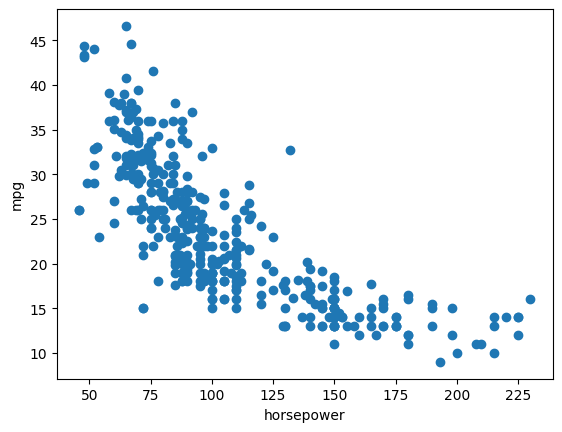

In [26]:
plt.scatter(df['horsepower'], df['mpg'])
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.show()

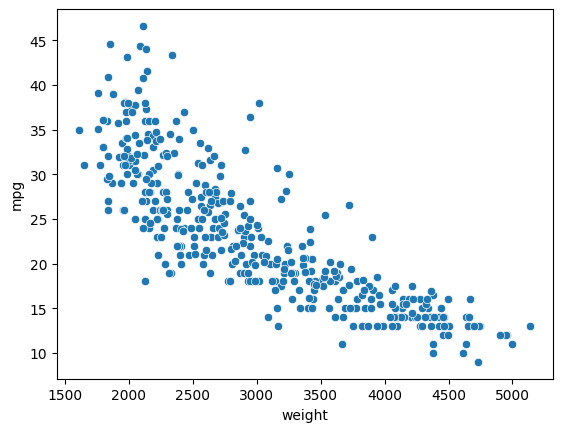

In [27]:
sns.scatterplot(x='weight', y='mpg', data=df)
plt.show()

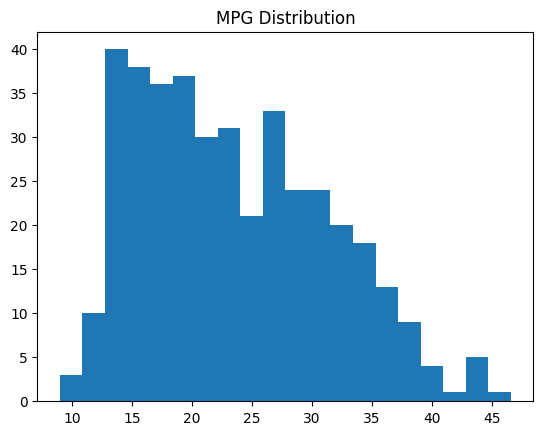

In [28]:
plt.hist(df['mpg'], bins=20)
plt.title("MPG Distribution")
plt.show()

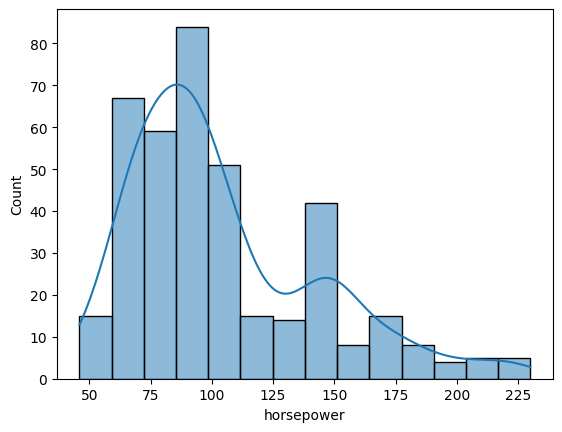

In [29]:
sns.histplot(df['horsepower'], kde=True)
plt.show()

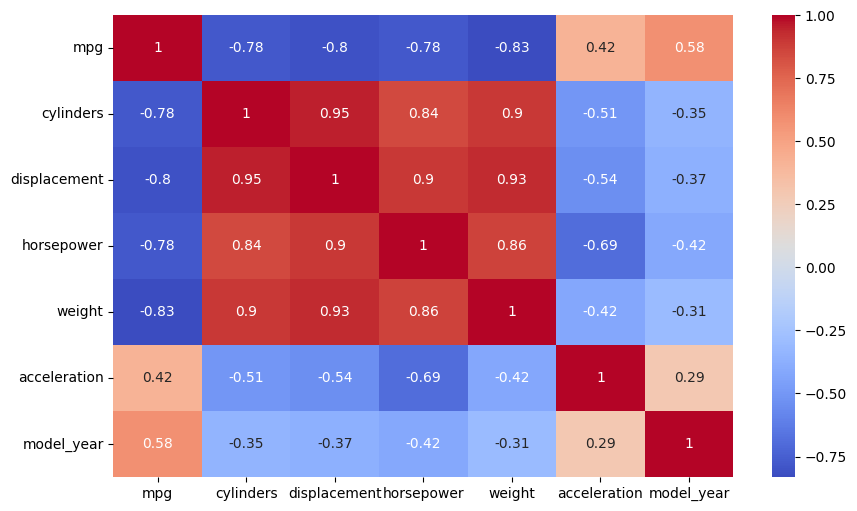

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

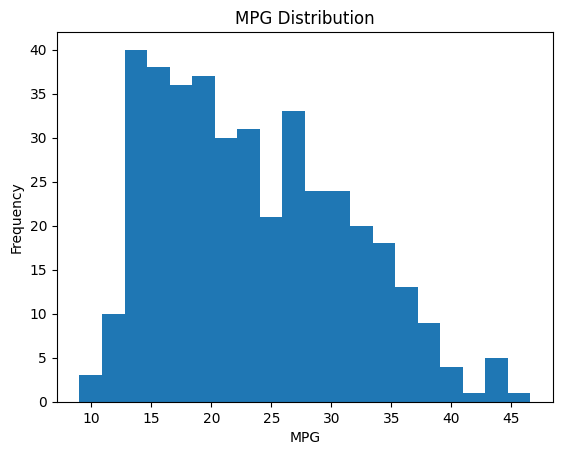

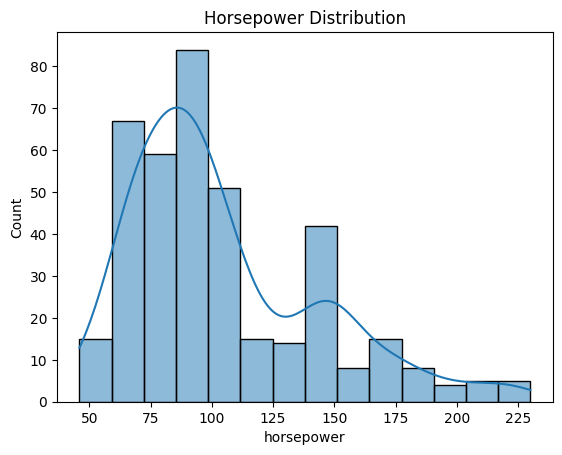

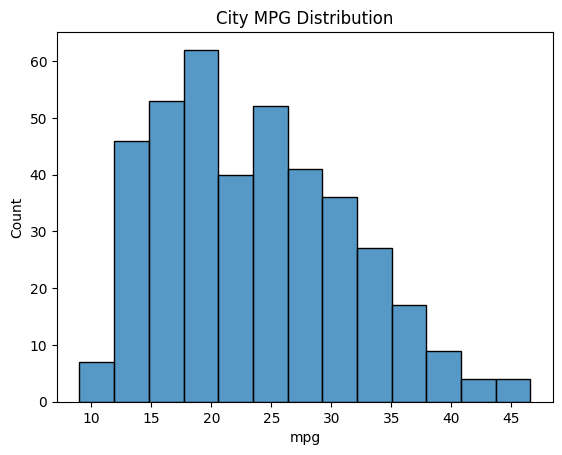

In [31]:
plt.hist(df['mpg'], bins=20)
plt.title("MPG Distribution")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()

sns.histplot(df['horsepower'], kde=True)
plt.title("Horsepower Distribution")
plt.show()

sns.histplot(df['mpg'])
plt.title("City MPG Distribution")
plt.show()

In [33]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/imports-85.csv"
df_auto = pd.read_csv(url)

df_auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [34]:
df_auto.columns
df_auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    int64  
 16  engine-size        205 non

In [35]:
df_auto['make'].value_counts()

df_auto['body-style'].value_counts()

df_auto['drive-wheels'].value_counts(normalize=True)

df_auto['fuel-system'].value_counts()

,count
fuel-system,
mpfi,94
2bbl,66
idi,20
1bbl,11
spdi,9
4bbl,3
mfi,1
spfi,1


In [36]:
# Average price by make
df_auto.groupby('make')['price'].mean()

# Average horsepower by body-style
df_auto.groupby('body-style')['horsepower'].mean()

# Average city-mpg by drive-wheels
df_auto.groupby('drive-wheels')['city-mpg'].mean()

# Min, max, mean price by body-style
df_auto.groupby('body-style')['price'].agg(['min','max','mean'])

# Make + body-style combination
df_auto.groupby(['make','body-style'])['price'].mean().sort_values(ascending=False)

make           body-style 
porsche        convertible    37028.000000
mercedes-benz  hardtop        36788.000000
               convertible    35056.000000
jaguar         sedan          34600.000000
porsche        hardtop        33278.000000
mercedes-benz  sedan          33074.000000
               wagon          28248.000000
bmw            sedan          26118.750000
porsche        hatchback      22018.000000
audi           wagon          18920.000000
volvo          sedan          18726.875000
toyota         convertible    17669.000000
audi           sedan          17647.000000
mercury        hatchback      16503.000000
alfa-romero    hatchback      16500.000000
volvo          wagon          16293.333333
peugot         sedan          15758.571429
saab           sedan          15433.333333
peugot         wagon          15017.500000
saab           hatchback      15013.333333
alfa-romero    convertible    14997.500000
nissan         hatchback      14409.000000
volkswagen     wagon          12290.000000
               convertible    11595.000000
mazda          sedan          11464.142857
isuzu          hatchback      11048.000000
mazda          hatchback      10085.000000
volkswagen     hatchback       9980.000000
honda          sedan           9945.000000
nissan         wagon           9915.666667
renault        hatchback       9895.000000
toyota         wagon           9836.000000
               hardtop         9762.333333
volkswagen     sedan           9673.888889
toyota         hatchback       9616.000000
mitsubishi     hatchback       9597.888889
toyota         sedan           9542.200000
subaru         wagon           9342.000000
renault        wagon           9295.000000
subaru         sedan           9070.600000
plymouth       wagon           8921.000000
dodge          wagon           8921.000000
nissan         sedan           8604.555556
mitsubishi     sedan           8434.000000
nissan         hardtop         8249.000000
plymouth       hatchback       8130.500000
dodge          hatchback       7819.800000
               sedan           7619.666667
honda          wagon           7295.000000
plymouth       sedan           7150.500000
honda          hatchback       7054.428571
isuzu          sedan           6785.000000
subaru         hatchback       6591.333333
chevrolet      sedan           6575.000000
               hatchback       5723.000000
audi           hatchback               NaN
Name: price, dtype: float64

In [37]:
corr = df_auto.corr(numeric_only=True)

corr

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
symboling,1.000000,0.528667,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.113129,-0.105790,-0.134205,-0.008965,-0.178515,0.071622,0.274573,-0.035823,0.034606,-0.082391
normalized-losses,0.528667,1.000000,-0.074362,0.023220,0.105073,-0.432335,0.119893,0.175380,0.167365,-0.036167,0.065627,-0.132654,0.295772,0.264597,-0.258502,-0.210768,0.203254
wheel-base,-0.531954,-0.074362,1.000000,0.874587,0.795144,0.589435,0.776386,0.339507,0.569329,0.490378,0.161477,0.249786,0.352297,-0.361052,-0.470414,-0.544082,0.584642
length,-0.357612,0.023220,0.874587,1.000000,0.841118,0.491029,0.877728,0.430672,0.683360,0.607480,0.129739,0.158414,0.555003,-0.287325,-0.670909,-0.704662,0.690628
width,-0.232919,0.105073,0.795144,0.841118,1.000000,0.279210,0.867032,0.545007,0.735433,0.559204,0.182956,0.181129,0.642482,-0.219957,-0.642704,-0.677218,0.751265
height,-0.541038,-0.432335,0.589435,0.491029,0.279210,1.000000,0.295572,-0.013995,0.067149,0.176195,-0.056999,0.261214,-0.110711,-0.322272,-0.048640,-0.107358,0.135486
curb-weight,-0.227691,0.119893,0.776386,0.877728,0.867032,0.295572,1.000000,0.609727,0.850594,0.649045,0.168929,0.151362,0.751034,-0.266306,-0.757414,-0.797465,0.834415
num-of-cylinders,-0.113129,0.175380,0.339507,0.430672,0.545007,-0.013995,0.609727,1.000000,0.846031,0.243553,0.008578,-0.020002,0.691633,-0.124434,-0.445837,-0.466666,0.708645
engine-size,-0.105790,0.167365,0.569329,0.683360,0.735433,0.067149,0.850594,0.846031,1.000000,0.594090,0.206675,0.028971,0.810773,-0.244618,-0.653658,-0.677470,0.872335
bore,-0.134205,-0.036167,0.490378,0.607480,0.559204,0.176195,0.649045,0.243553,0.594090,1.000000,-0.055909,0.005203,0.577273,-0.264269,-0.594584,-0.594572,0.543436


In [38]:
corr.unstack().sort_values(ascending=False)

,,0
price,price,1.000000
highway-mpg,highway-mpg,1.000000
normalized-losses,normalized-losses,1.000000
city-mpg,city-mpg,1.000000
peak-rpm,peak-rpm,1.000000
...,...,...
horsepower,highway-mpg,-0.770908
curb-weight,highway-mpg,-0.797465
highway-mpg,curb-weight,-0.797465
horsepower,city-mpg,-0.803620


In [39]:
corr['price'].sort_values(ascending=False)

,price
price,1.000000
engine-size,0.872335
curb-weight,0.834415
horsepower,0.810533
width,0.751265
num-of-cylinders,0.708645
length,0.690628
wheel-base,0.584642
bore,0.543436
normalized-losses,0.203254


In [40]:
corr['price']['horsepower']
corr['price']['city-mpg']

np.float64(-0.6865710067844684)

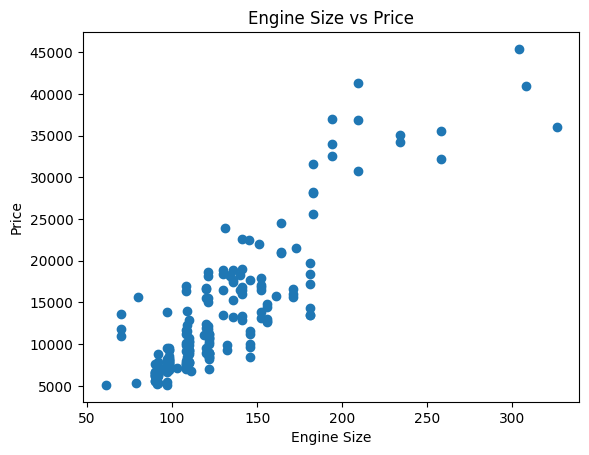

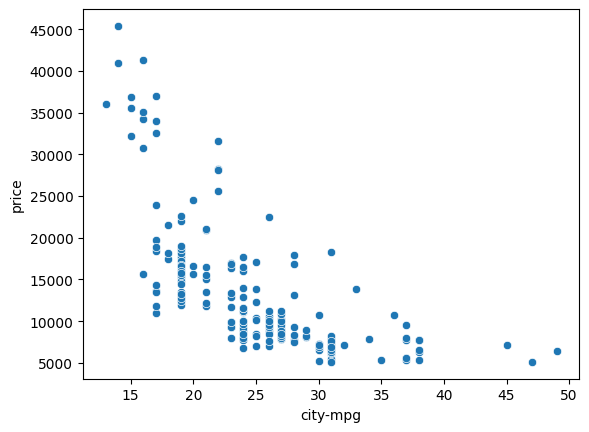

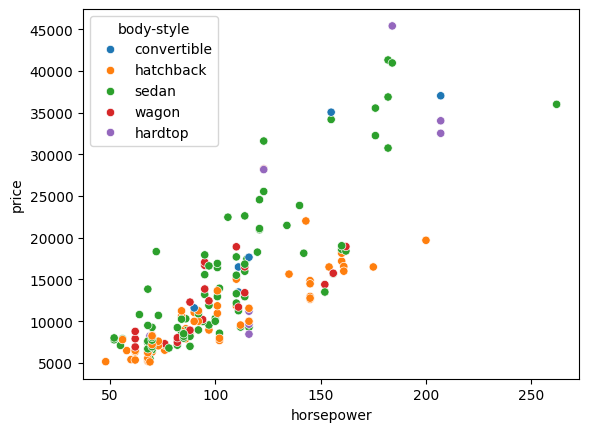

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(df_auto['engine-size'], df_auto['price'])
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.title("Engine Size vs Price")
plt.show()

sns.scatterplot(x='city-mpg', y='price', data=df_auto)
plt.show()

sns.scatterplot(x='horsepower', y='price', hue='body-style', data=df_auto)
plt.show()

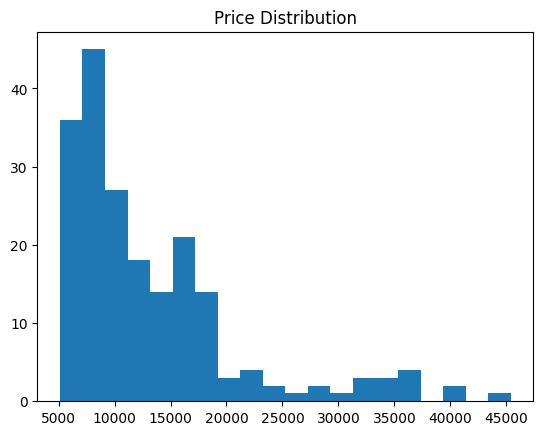

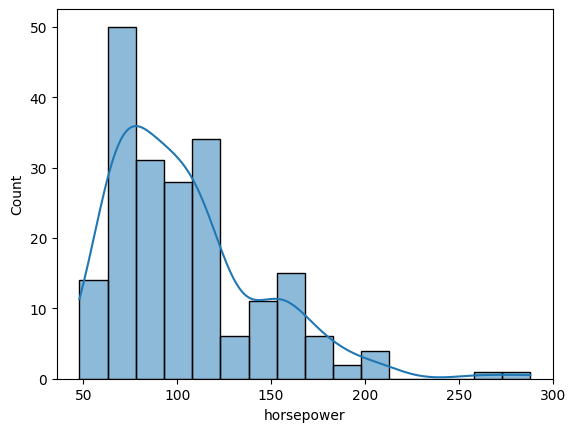

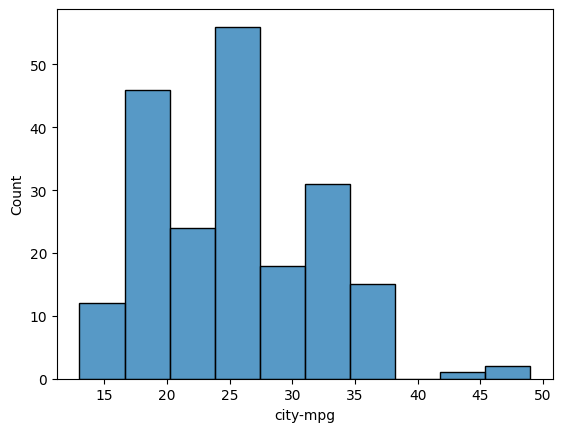

In [42]:
plt.hist(df_auto['price'], bins=20)
plt.title("Price Distribution")
plt.show()

sns.histplot(df_auto['horsepower'], kde=True)
plt.show()

sns.histplot(df_auto['city-mpg'])
plt.show()

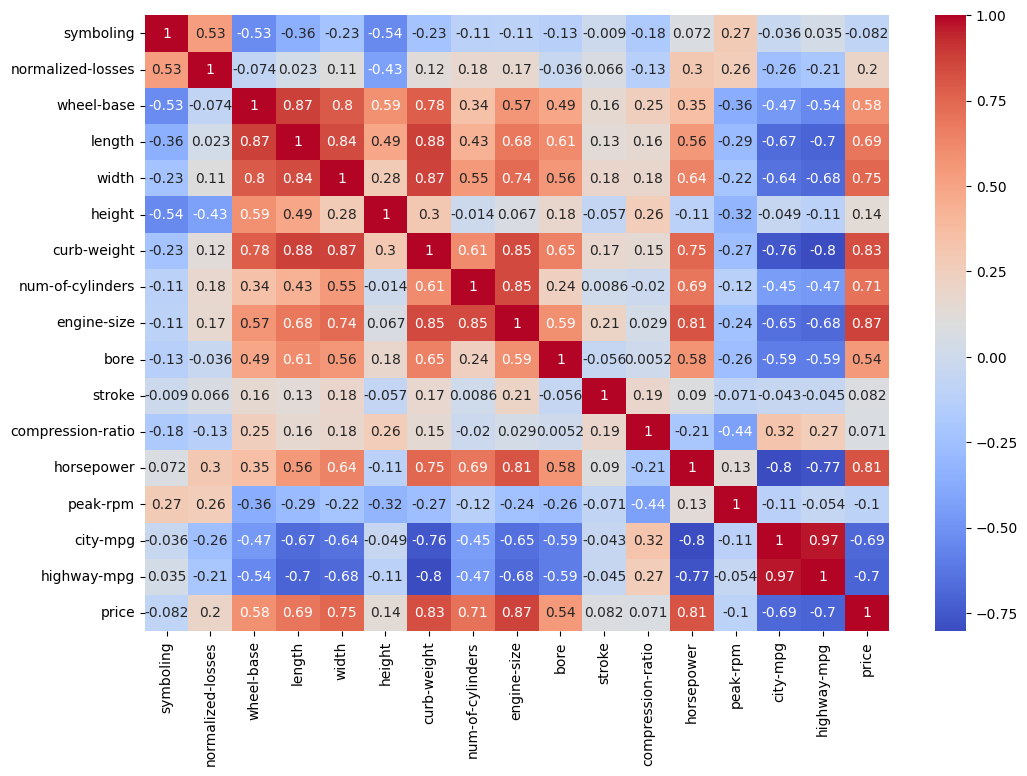

In [43]:
plt.figure(figsize=(12,8))
sns.heatmap(df_auto.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Engine-size and horsepower have strong positive correlation with price
Top 3 features affecting price are engine-size, horsepower, and curb-weight
Horsepower and price show a positive relationship
City-mpg and price have a negative relationship (higher mileage → lower price)
Scatter plots show:
Engine size vs price → positive trend
City-mpg vs price → negative trend
High horsepower & price cars are mostly sedans and luxury models
Histogram shows:
Price distribution is right-skewed
Most cars fall in mid-price range
Horsepower is concentrated in moderate range
Heatmap shows:
Strong positive correlation: engine-size & price
Strong negative correlation: city-mpg & price
